In [8]:
import pip
pip.main(['install','seaborn'])

Please see https://github.com/pypa/pip/issues/5599 for advice on fixing the underlying issue.
To avoid this problem you can invoke Python with '-m pip' instead of running pip directly.


Collecting seaborn

Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)

Requirement already satisfied: numpy!=1.24.0,>=1.20 in /Users/uenakayuto/main-research/GELID-replication-package/.venv/lib/python3.12/site-packages (from seaborn) (1.26.4)

Requirement already satisfied: pandas>=1.2 in /Users/uenakayuto/main-research/GELID-replication-package/.venv/lib/python3.12/site-packages (from seaborn) (2.2.2)

...

Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

Installing collected packages: seaborn

Successfully installed seaborn-0.13.2

[notice] A new release of pip is available: 24.0 -> 24.1.2
[notice] To update, run: pip install --upgrade pip

0

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

In [10]:
df = pd.read_csv('similarity.csv')
df

,f_0,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,f_9,...,f_20,f_21,f_22,f_23,f_24,f_25,f_26,f_27,f_28,f_29
0,0.000000,0.680728,1.008069,1.011779,1.009182,1.010824,1.016381,0.971233,0.712448,0.509709,...,0.976987,0.847156,0.997533,0.996081,0.996081,0.982200,0.998283,0.745683,0.860939,0.838239
1,0.680728,0.000000,1.014076,1.021197,1.016178,1.019332,1.029749,0.888813,0.719104,0.591397,...,0.974801,0.873657,0.969221,0.971633,0.971633,0.960141,0.969797,0.442745,0.964733,0.842918
2,1.008069,1.014076,0.000000,0.988403,0.105590,0.289495,0.605984,1.007872,1.009454,1.010009,...,1.005133,1.008363,1.002039,1.002366,1.002366,1.005781,1.002365,1.013437,1.010012,1.007585
3,1.011779,1.021197,0.988403,0.000000,0.968442,0.992016,0.892220,1.010917,1.014444,1.015130,...,1.007128,1.011643,1.002915,1.003442,1.003442,1.009074,1.003390,1.020153,1.014930,1.006706
4,1.009182,1.016178,0.105590,0.968442,0.000000,0.310893,0.619263,1.008532,1.012178,1.011288,...,1.005808,1.009447,1.002339,1.002724,1.002724,1.006573,1.002711,1.016188,1.010901,1.008464
5,1.010824,1.019332,0.289495,0.992016,0.310893,0.000000,0.440788,1.010412,1.013665,1.013833,...,1.005763,1.010975,1.002740,1.003059,1.003059,1.008386,1.003137,1.019046,1.013607,1.008819
6,1.016381,1.029749,0.605984,0.892220,0.619263,0.440788,0.000000,1.014909,1.021874,1.020554,...,1.010954,1.016959,1.004043,1.004827,1.004827,1.011788,1.004695,1.028578,1.020228,1.017103
7,0.971233,0.888813,1.007872,1.010917,1.008532,1.010412,1.014909,0.000000,0.974776,0.925184,...,1.010928,0.911233,1.000058,1.003240,1.003240,0.955261,0.999536,0.923463,0.849157,0.856735
8,0.712448,0.719104,1.009454,1.014444,1.012178,1.013665,1.021874,0.974776,0.000000,0.584881,...,0.986780,0.899225,0.995443,1.003271,1.003271,0.980040,0.991700,0.626121,0.904078,0.756651
9,0.509709,0.591397,1.010009,1.015130,1.011288,1.013833,1.020554,0.925184,0.584881,0.000000,...,0.984755,0.810891,0.931600,0.905697,0.905697,0.943946,0.904358,0.646432,0.750825,0.680851


In [11]:
from sklearn.neighbors import NearestNeighbors # importing the library
neighb = NearestNeighbors(n_neighbors=2) # creating an object of the NearestNeighbors class, which can be same as the minPts value
nbrs=neighb.fit(df) # fitting the data to the object
distances,indices=nbrs.kneighbors(df)

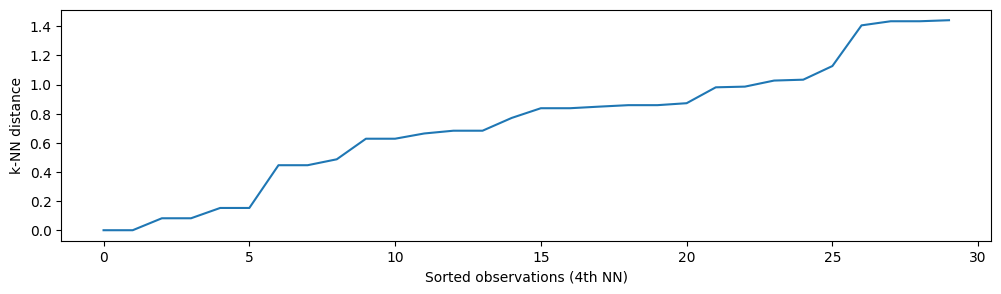

0.15288392574954984


In [12]:
# Sort and plot the distances results
distances = np.sort(distances, axis = 0) # sorting the distances
distances = distances[:, 1] # taking the second column of the sorted distances
plt.rcParams['figure.figsize'] = (12,3) # setting the figure size
plt.plot(distances) # plotting the distances
plt.ylabel("k-NN distance")
plt.xlabel("Sorted observations (4th NN)")
plt.show()
best = 0
best_delta = 0
for i in range(0, len(distances)):
  if distances[i] - distances[i-1] > best_delta:
    best_delta = distances[i] - distances[i-1]
    best = distances[i-1]

print(best)


In [13]:
clustering = DBSCAN(min_samples=2, eps=best, metric='precomputed').fit(df)
DBSCAN_dataset = df.copy()
DBSCAN_dataset.loc[:,'Cluster'] = clustering.labels_

In [14]:
labels = clustering.labels_
print(labels)
# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

[-1 -1  0 -1  0 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1  2
  2 -1  1 -1 -1 -1]
Estimated number of clusters: 3
Estimated number of noise points: 24


In [ ]:
DBSCAN_dataset.Cluster.to_frame()

,Cluster
0,-1
1,-1
2,0
3,0
4,-1
5,-1
6,-1
7,-1
8,-1
9,-1
